## Chapter 11 - Applied

In [89]:
# Imports
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import numpy as np
import pandas as pd
from ISLP.models import ModelSpec as MS
from ISLP import load_data

# New imports
from lifelines import (
    KaplanMeierFitter,
    CoxPHFitter
)
from lifelines.statistics import (
    logrank_test,
    multivariate_logrank_test
)
from ISLP.survival import sim_time

### Question 10

#### 10a)

In [2]:
# Load & quick explore data
brain_cancer = pd.read_csv('data/BrainCancer.csv')
brain_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  88 non-null     int64  
 1   sex         88 non-null     object 
 2   diagnosis   87 non-null     object 
 3   loc         88 non-null     object 
 4   ki          88 non-null     int64  
 5   gtv         88 non-null     float64
 6   stereo      88 non-null     object 
 7   status      88 non-null     int64  
 8   time        88 non-null     float64
dtypes: float64(2), int64(3), object(4)
memory usage: 6.3+ KB


In [3]:
# Check initial observations
brain_cancer.head()

,Unnamed: 0,sex,diagnosis,loc,ki,gtv,stereo,status,time
0,1,Female,Meningioma,Infratentorial,90,6.11,SRS,0,57.64
1,2,Male,HG glioma,Supratentorial,90,19.35,SRT,1,8.98
2,3,Female,Meningioma,Infratentorial,70,7.95,SRS,0,26.46
3,4,Female,LG glioma,Supratentorial,80,7.61,SRT,1,47.80
4,5,Male,HG glioma,Supratentorial,90,5.06,SRT,1,6.30


In [4]:
# Drop first column and missing data
brain_cancer = brain_cancer.iloc[:, 1:]
brain_cancer.dropna(inplace=True)

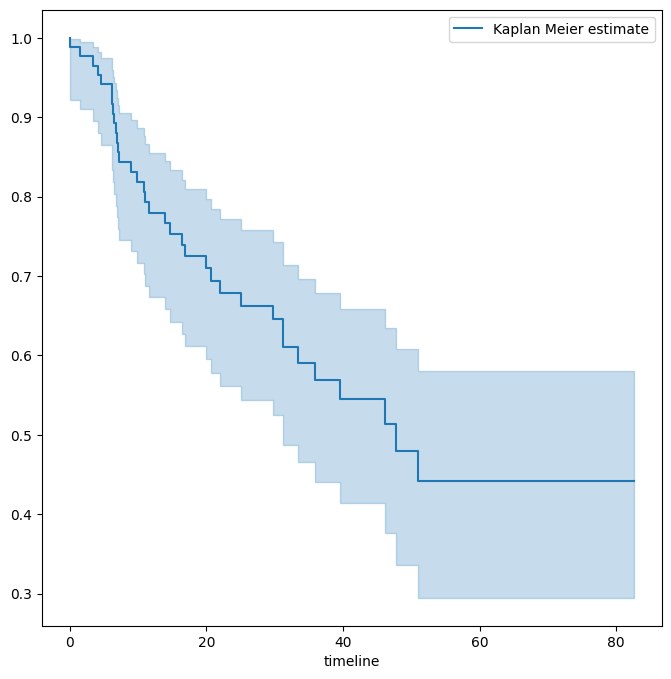

In [70]:
# Kaplan-Meier survival curve
fig, ax = subplots(figsize=(8,8))
km = KaplanMeierFitter()
km_brain = km.fit(brain_cancer['time'], brain_cancer['status'])
km_brain.plot(label='Kaplan Meier estimate', ax=ax);

In [71]:
# Initial/original Kaplan-Meier predictions
pred_initial = km_brain.predict(brain_cancer['time'])
pred_initial

time
57.64    0.442182
8.98     0.830780
26.46    0.662498
47.80    0.479031
6.30     0.904469
           ...   
20.69    0.694081
6.39     0.892247
32.82    0.610618
42.07    0.545325
13.90    0.779592
Name: KM_estimate, Length: 87, dtype: float64

#### 10b)

In [72]:
# Get the survival function
km_survival_function = km_brain.survival_function_
km_survival_function

,KM_estimate
timeline,
0.00,1.000000
0.07,0.988506
1.18,0.988506
1.41,0.976876
1.54,0.976876
...,...
65.02,0.442182
67.38,0.442182
73.74,0.442182


In [ ]:
# Initial/original Kaplan-Meier predictions
pred_initial = km_brain.predict(km_survival_function.index)

# Bootstrap variables
B = 200
N = 88 
CI = 95
alpha = (100 - CI)/2

rng = np.random.default_rng(0)
km = KaplanMeierFitter()

km_list = []
preds = pd.DataFrame()
deltas = pd.DataFrame()

for _ in range(B):
    # Sample & fit Kaplan-Meier
    idx = rng.choice(brain_cancer.index, size=N, replace=True)
    X_ = brain_cancer.loc[idx]
    km_brain = km.fit(X_['time'], X_['status'])
    km_list.append(km_brain)

    # Predict & update dataframe
    pred = km_brain.predict(km_survival_function.index)
    preds = pd.concat((preds, pred), axis=1)

    # Compute delta
    delta = pred - pred_initial
    deltas = pd.concat((deltas, delta), axis=1)

# Mean of predictions
mean = preds.mean(axis=1)

# Construct the std bounds
upper_delta = np.percentile(deltas, alpha, axis=1)
upper_bound = pred_initial - upper_delta

lower_delta = np.percentile(deltas, 100-alpha, axis=1)
lower_bound = pred_initial - lower_delta

In [128]:
# Kaplan-Meier CI
km = KaplanMeierFitter()
km_brain = km.fit(brain_cancer['time'], brain_cancer['status'])
km_brain.confidence_interval_

,KM_estimate_lower_0.95,KM_estimate_upper_0.95
0.00,1.000000,1.000000
0.07,0.921206,0.998373
1.18,0.921206,0.998373
1.41,0.910689,0.994167
1.54,0.910689,0.994167
...,...,...
65.02,0.294775,0.579762
67.38,0.294775,0.579762
73.74,0.294775,0.579762
78.75,0.294775,0.579762


In [78]:
# Bootstrap CI
boot_ci = pd.concat((lower_bound, upper_bound), axis=1)
boot_ci.sort_index(inplace=True)
boot_ci.columns = ['KM_estimate_lower_95', 'KM_estimate_upper_95']

# CI cannot go over 1
boot_ci['KM_estimate_upper_95'] = boot_ci['KM_estimate_upper_95'].apply(
    lambda x: 1 if x>1 else x
)
boot_ci

,KM_estimate_lower_95,KM_estimate_upper_95
timeline,,
0.00,1.000000,1.000000
0.07,0.977011,1.011102
1.18,0.977011,1.011102
1.41,0.953753,1.011125
1.54,0.953753,1.011125
...,...,...
65.02,0.301567,0.594184
67.38,0.301567,0.594184
73.74,0.301567,0.594184


In [115]:
# Check Bootstrap Standard Error
sample_std = np.std(deltas, axis=1, ddof=1)
sample_size = len(deltas)
standard_error = sample_std / np.sqrt(sample_size)
standard_error.rename('standard_error_boot', inplace=True)


0.00     0.000000
0.07     0.001102
1.18     0.001102
1.41     0.001688
1.54     0.001688
           ...   
65.02    0.007833
67.38    0.007833
73.74    0.007833
78.75    0.007833
82.56    0.007833
Name: standard_error_boot, Length: 86, dtype: float64

''

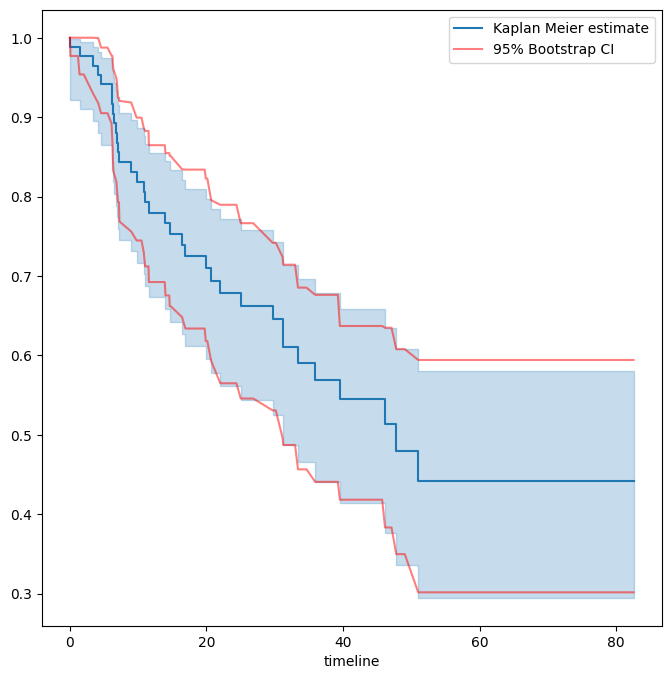

In [101]:
# Plot & compare both CIs
fig, ax = subplots(figsize=(8,8))
km = KaplanMeierFitter()
km_brain = km.fit(brain_cancer['time'], brain_cancer['status'])
km_brain.plot(label='Kaplan Meier estimate', ax=ax)
#plt.plot(mean, label='Bootstrap estimate', color='r')
plt.plot(
    boot_ci['KM_estimate_upper_95'],
    label='95% Bootstrap CI',
    color='r',
    alpha=0.5

)
plt.plot(
    boot_ci['KM_estimate_lower_95'],
    color='r',
    alpha=0.5
)
plt.legend();

As shown above, the CIs constructed using the standard errors are quite similar. The red line represents the bootstrap-based CI (200 iterations), while the blue shaded area represents the CI estimated from the Kaplan-Meier survival curve.

#### 10c)

In [112]:
# Cox proportional hazards model
coxph = CoxPHFitter
brain_dummies = pd.get_dummies(brain_cancer, drop_first=True)
fit_all = coxph().fit(brain_dummies, 'time', 'status')
fit_all.summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
ki,-0.054955,0.018314,0.002693
gtv,0.034293,0.022333,0.124661
sex_Male,0.183748,0.360358,0.610119
diagnosis_LG glioma,-1.239530,0.579555,0.032455
diagnosis_Meningioma,-2.154566,0.450524,0.000002
diagnosis_Other,-1.268870,0.617672,0.039949
loc_Supratentorial,0.441195,0.703669,0.530665
stereo_SRT,0.177778,0.601578,0.767597


The Cox proportional hazards model fitted with all features reveals four statistically significant covariates: 'ki', 'diagnosis_LG_glioma', 'diagnosis_Meningioma', and 'diagnosis_Other'.

In [113]:
# Compare the model to one with no features
fit_all.log_likelihood_ratio_test()

<lifelines.StatisticalResult: log-likelihood ratio test>
null_distribution = chi squared
  degrees_freedom = 8
        test_name = log-likelihood ratio test

---
 test_statistic      p  -log2(p)
          41.37 <0.005     19.10

Based on the log-likelihood ratio test, the Cox proportional hazards model that includes all features offers a significantly improved fit compared to the null model.

#### 10d)

In [135]:
# Explore 'ki' values
brain_cancer['ki'].value_counts()

ki
80     36
90     26
70     14
100     5
60      5
40      1
Name: count, dtype: int64

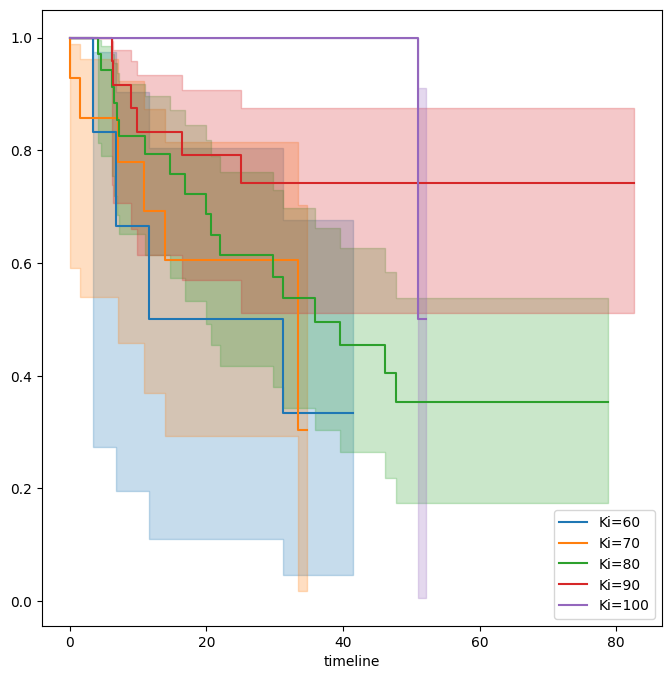

In [142]:
# Replace the single 40 'ki' value by 60
brain_cancer_adapted = brain_cancer.copy()
brain_cancer_adapted['ki'] = brain_cancer_adapted['ki']\
    .replace(40, 60)

# Plot Kaplan-Meier survival stratified by 'ki'
fig, ax = subplots(figsize=(8,8))
by_ki = {}
for ki, df in brain_cancer_adapted.groupby('ki'):
    by_ki[ki] = df
    km_ki = km.fit(df['time'], df['status'])
    km_ki.plot(label=f'Ki={ki}', ax=ax)

---

### Question 11

#### 11a)

In [157]:
# Get data from Table 11.4 (p.506)
y = [26.5, 37.2, 57.3, 90.8, 20.2, 89.8]
censoring_dummy = [1, 1, 1, 0, 0, 0]
x = [0.1, 11, -0.3, 2.8, 1.8, 0.4]

# Create a dataframe
table_df = pd.DataFrame({
    'y': y,
    'censoring': censoring_dummy,
    'x': x
})

# Create 2 groups
table_df['group'] = table_df['x'].apply(
    lambda x: 'group 1' if x<2 else 'group 2'
)
table_df

,y,censoring,x,group
0,26.5,1,0.1,group 1
1,37.2,1,11.0,group 2
2,57.3,1,-0.3,group 1
3,90.8,0,2.8,group 2
4,20.2,0,1.8,group 1
5,89.8,0,0.4,group 1


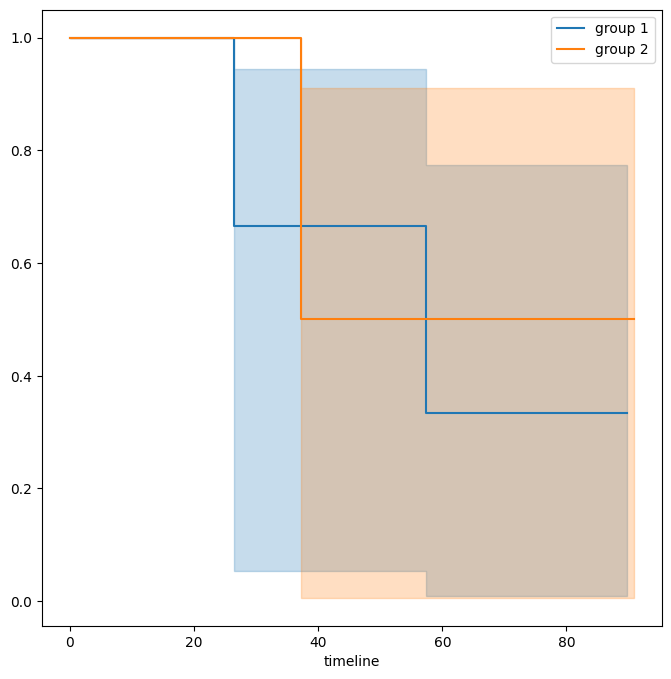

In [158]:
# Fit & plot Kaplan-Meier survival curves
fig, ax = subplots(figsize=(8,8))
by_group = {}
for group, df in table_df.groupby('group'):
    by_group[group] = df
    km_sex = km.fit(df['y'], df['censoring'])
    km_sex.plot(label=f'{group}', ax=ax)

As shown in the graphs above, there is no apparent difference between 'group 1' and 'group 2'. The two curves lie close to each other, and their CI overlap considerably, suggesting no significant separation between the groups.

#### 11b)

In [159]:
# Cox proportional hazards model
coxph = CoxPHFitter
cols = ['y', 'censoring', 'group']
table_df_dummies = pd.get_dummies(
    table_df[cols], 
    drop_first=True
)
fit = coxph().fit(table_df_dummies, 'y', 'censoring')
fit.summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
group_group 2,-0.340143,1.235876,0.783144


In [164]:
# Print coefficients
print(
    round(np.exp(0.3401), 4),
    round(np.exp(-0.3401), 4)
)

1.4051 0.7117


The estimated coefficient is –0.3401, indicating that 'group 1' has approximately 1.4 times the risk of experiencing event 'y' compared to 'group 2'. In other words, 'group 2' has about 0.71 times (or 71%) the risk relative to 'group 1'.

However, the p-value of 0.7821 suggests that this difference is not statistically significant. Therefore, there is no sufficient evidence to conclude that the true coefficient differs from zero.

#### 11c)

In [165]:
# Compare the model to one with no features - log-rank test
fit.log_likelihood_ratio_test()

<lifelines.StatisticalResult: log-likelihood ratio test>
null_distribution = chi squared
  degrees_freedom = 1
        test_name = log-likelihood ratio test

---
 test_statistic    p  -log2(p)
           0.08 0.78      0.36

The log-rank test statistic provides the same p-value from the coefficient of the Cox model from item 11b).